# Análise Horizontal da DRE — Empresas Listadas na B3

---

A análise horizontal é uma técnica de avaliação financeira que compara a evolução
de cada conta do demonstrativo ao longo do tempo, tomando um ano-base como referência.
O resultado expressa, em percentual, o quanto cada conta cresceu ou retraiu em relação
a esse ponto de partida.

Neste estudo, coletamos a DRE consolidada de uma empresa listada na B3 diretamente
da CVM, estruturamos os dados em formato de painel (contas × anos) e calculamos
a variação acumulada de cada conta em relação ao ano-base escolhido.

**Fonte dos dados:** http://dados.cvm.gov.br

## Dependências e Configurações Iniciais

---

Carregamento das bibliotecas e configuração do logger.

In [43]:
import tempfile
import requests
from   zipfile import ZipFile
from   pathlib import Path
from   loguru  import logger

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

logger.info('BIBLIOTECAS CARREGADAS')

2026-06-11 18:29:29.264 | INFO     | __main__:<module>:11 - BIBLIOTECAS CARREGADAS


## Constantes e Configurações

---

In [2]:
DATA            = Path().cwd() / 'dados'
DATA.mkdir(parents=True, exist_ok=True)

URL_BASE        = 'https://dados.cvm.gov.br/dados/CIA_ABERTA/DOC/DFP/DADOS/'
ANO_INICIO      = 2010
ANO_FIM         = 2025
DEMONSTRATIVO   = 'DRE_con'
ARQUIVOS_ZIP    = [f'dfp_cia_aberta_{ano}.zip' for ano in range(ANO_INICIO, ANO_FIM + 1)]

logger.info('CONSTANTES CARREGADAS')

2026-06-11 16:51:19.914 | INFO     | __main__:<module>:10 - CONSTANTES CARREGADAS


## 1. Coleta de Arquivos na CVM

---

Download e extração dos arquivos `.zip` anuais disponibilizados pela CVM.
O processo é idêntico ao utilizado no estudo de P/L histórico.

In [3]:
logger.info('Iniciando download e extração de arquivos CSVs')
logger.info(f'Total de arquivos para download: {len(ARQUIVOS_ZIP)}')

with tempfile.TemporaryDirectory() as temp:
    temp_path = Path(temp)

    for arquivo in ARQUIVOS_ZIP:
        url_completa = URL_BASE + arquivo
        caminho_zip  = temp_path / arquivo

        try:
            logger.info(f'Baixando: {arquivo}')
            resposta = requests.get(url_completa, stream=True)
            resposta.raise_for_status()

            with open(caminho_zip, 'wb') as f:
                for chunk in resposta.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)

            logger.info(f'Extraindo {arquivo}...')
            with ZipFile(caminho_zip, 'r') as zip_ref:
                zip_ref.extractall(DATA)

        except requests.exceptions.HTTPError:
            logger.exception(f'Erro HTTP ao tentar baixar {arquivo}')
        except Exception:
            logger.exception(f'Erro genérico ao processar {arquivo}')

logger.info('Processo concluído com sucesso')

2026-06-11 16:54:02.768 | INFO     | __main__:<module>:1 - Iniciando download e extração de arquivos CSVs
2026-06-11 16:54:02.769 | INFO     | __main__:<module>:2 - Total de arquivos para download: 16
2026-06-11 16:54:02.772 | INFO     | __main__:<module>:12 - Baixando: dfp_cia_aberta_2010.zip
2026-06-11 16:54:03.632 | INFO     | __main__:<module>:21 - Extraindo dfp_cia_aberta_2010.zip...
2026-06-11 16:54:05.607 | INFO     | __main__:<module>:12 - Baixando: dfp_cia_aberta_2011.zip
2026-06-11 16:54:06.187 | INFO     | __main__:<module>:21 - Extraindo dfp_cia_aberta_2011.zip...
2026-06-11 16:54:08.128 | INFO     | __main__:<module>:12 - Baixando: dfp_cia_aberta_2012.zip
2026-06-11 16:54:08.778 | INFO     | __main__:<module>:21 - Extraindo dfp_cia_aberta_2012.zip...
2026-06-11 16:54:10.466 | INFO     | __main__:<module>:12 - Baixando: dfp_cia_aberta_2013.zip
2026-06-11 16:54:11.086 | INFO     | __main__:<module>:21 - Extraindo dfp_cia_aberta_2013.zip...
2026-06-11 16:54:12.767 | INFO     

## 2. Carregando a DRE

---

Leitura e concatenação de todos os CSVs de DRE consolidada extraídos na etapa anterior.

In [6]:
logger.info('Buscando arquivos CSV com DRE')

arquivos_csv     = list(DATA.glob('*.csv'))
arquivos_csv_dre = [a for a in arquivos_csv if DEMONSTRATIVO in a.name]

logger.info(f'Total de arquivos encontrados: {len(arquivos_csv_dre)}')

lista_df = [
    pd.read_csv(a, sep=';', encoding='ISO-8859-1', decimal=',', dtype=str)
    for a in arquivos_csv_dre
]

df = pd.concat(lista_df, ignore_index=True)
logger.info(f'DataFrame concatenado: {df.shape[0]} linhas, {df.shape[1]} colunas')

2026-06-11 16:57:19.523 | INFO     | __main__:<module>:1 - Buscando arquivos CSV com DRE
2026-06-11 16:57:19.530 | INFO     | __main__:<module>:6 - Total de arquivos encontrados: 16
2026-06-11 16:57:20.547 | INFO     | __main__:<module>:14 - DataFrame concatenado: 449570 linhas, 15 colunas


## 3. Tratamento dos Dados

---

Conversão de tipos e filtro para manter apenas o exercício mais recente
de cada empresa por período, eliminando reapresentações e versões anteriores.

In [7]:
logger.info('Iniciar tratamento dos dados')
logger.info(f'Antes do filtro: {df.shape[0]} linhas')
df = df.assign(
    DT_REFER     = pd.to_datetime(df['DT_REFER']),
    DT_INI_EXERC = pd.to_datetime(df['DT_INI_EXERC']),
    DT_FIM_EXERC = pd.to_datetime(df['DT_FIM_EXERC']),
    VERSAO       = pd.to_numeric(df['VERSAO']),
    VL_CONTA     = pd.to_numeric(df['VL_CONTA']),
)

df = df[df['ORDEM_EXERC'] == 'ÚLTIMO']

logger.info(f'Após filtro: {df.shape[0]} linhas')
logger.info('Tratamento dos dados concluído')

2026-06-11 16:57:26.771 | INFO     | __main__:<module>:1 - Iniciar tratamento dos dados
2026-06-11 16:57:26.772 | INFO     | __main__:<module>:2 - Antes do filtro: 449570 linhas
2026-06-11 16:57:27.241 | INFO     | __main__:<module>:13 - Após filtro: 225197 linhas
2026-06-11 16:57:27.242 | INFO     | __main__:<module>:14 - Tratamento dos dados concluído


## 4. Selecionando a Empresa

---

Busca textual pelo nome da empresa e confirmação do código CVM.
Para trocar a empresa de análise, basta alterar a variável `cia` abaixo.

In [15]:
cia  = 'itaúsa' 
df \
    [['CD_CVM', 'DENOM_CIA']] \
    .drop_duplicates()        \
    .set_index('CD_CVM')      \
    .query("DENOM_CIA.str.contains(@cia, case=False)") \
    # .index[0]

,DENOM_CIA
CD_CVM,
007617,ITAÚSA S.A.


In [16]:
df[df['CD_CVM'] == '007617' ]['DENOM_CIA'].unique()

array(['ITAÚSA S.A.'], dtype=object)

## 5. Contas Disponíveis na DRE
---
Inspeção das contas presentes na DRE da empresa selecionada.
Útil para identificar quais contas incluir na análise horizontal.

In [17]:
df \
    .loc[df['CD_CVM'] == '007617', ['CD_CONTA', 'DS_CONTA']] \
    .drop_duplicates() \
    .set_index("CD_CONTA")

,DS_CONTA
CD_CONTA,
3.01,Receita de Venda de Bens e/ou Serviços
3.02,Custo dos Bens e/ou Serviços Vendidos
3.03,Resultado Bruto
3.04,Despesas/Receitas Operacionais
3.04.01,Despesas com Vendas
3.04.02,Despesas Gerais e Administrativas
3.04.03,Perdas pela Não Recuperabilidade de Ativos
3.04.04,Outras Receitas Operacionais
3.04.05,Outras Despesas Operacionais


## 6. Estruturando o Painel - Contas × Anos
---
Filtramos a DRE da empresa e extraímos o ano de cada registro.
Em seguida, pivotamos o DataFrame para obter contas nas linhas
e anos nas colunas, estrutura base para a análise horizontal.

O `aggfunc='last'` garante que, havendo múltiplas versões para
o mesmo ano, fique apenas a mais recente.

In [18]:
dre = df[ df['CD_CVM'] == '007617' ].copy()
dre['ANO'] = dre['DT_REFER'].dt.year
dre.sample()

,CNPJ_CIA,DT_REFER,VERSAO,DENOM_CIA,CD_CVM,GRUPO_DFP,MOEDA,ESCALA_MOEDA,ORDEM_EXERC,DT_INI_EXERC,DT_FIM_EXERC,CD_CONTA,DS_CONTA,VL_CONTA,ST_CONTA_FIXA,ANO
223204,61.532.644/0001-15,2018-12-31,1,ITAÚSA S.A.,007617,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2018-01-01,2018-12-31,3.05,Resultado Antes do Resultado Financeiro e dos ...,9927000.0,S,2018


In [39]:
dre_painel = dre.pivot_table(
    index   = ['CD_CONTA', 'DS_CONTA'],
    columns = 'ANO',
    values  = 'VL_CONTA',
    aggfunc = 'last'
)
dre_painel

,ANO,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
CD_CONTA,DS_CONTA,,,,,,,,,,,,,,,,
3.01,Receita de Venda de Bens e/ou Serviços,5240000.00,5094000.0,5653000.00,5289000.00,5021000.0,4885000.00,4687000.00,4969000.00,5375000.00,5008000.00,5.880000e+06,8.170000e+06,8.486000e+06,7.383000e+06,8.235000e+06,8.249000e+06
3.02,Custo dos Bens e/ou Serviços Vendidos,-3624000.00,-3279000.0,-4037000.00,-3729000.00,-3767000.0,-3731000.00,-3641000.00,-3674000.00,-4011000.00,-3718000.00,-4.028000e+06,-5.296000e+06,-5.611000e+06,-5.006000e+06,-5.783000e+06,-6.239000e+06
3.03,Resultado Bruto,1616000.00,1815000.0,1616000.00,1560000.00,1254000.0,1154000.00,1046000.00,1295000.00,1364000.00,1290000.00,1.852000e+06,2.874000e+06,2.875000e+06,2.377000e+06,2.452000e+06,2.010000e+06
3.04,Despesas/Receitas Operacionais,-15830000.00,-14021000.0,-14448000.00,4924000.00,7069000.0,7914000.00,7183000.00,7295000.00,8563000.00,9704000.00,5.872000e+06,1.022300e+07,1.269400e+07,1.173300e+07,1.393600e+07,1.610900e+07
3.04.01,Despesas com Vendas,0.00,0.0,0.00,-553000.00,-582000.0,-621000.00,-629000.00,-686000.00,-721000.00,-716000.00,-7.810000e+05,-1.006000e+06,-1.120000e+06,-1.042000e+06,-1.225000e+06,-1.189000e+06
3.04.02,Despesas Gerais e Administrativas,-14054000.00,-11770000.0,-12256000.00,-332000.00,-300000.0,-316000.00,-307000.00,-322000.00,-319000.00,-387000.00,-4.150000e+05,-5.070000e+05,-5.480000e+05,-5.820000e+05,-5.420000e+05,-5.560000e+05
3.04.03,Perdas pela Não Recuperabilidade de Ativos,0.00,0.0,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
3.04.04,Outras Receitas Operacionais,1041000.00,1083000.0,1163000.00,164000.00,201000.0,23000.00,124000.00,306000.00,133000.00,535000.00,8.800000e+04,1.339000e+06,2.883000e+06,1.027000e+06,3.340000e+05,3.460000e+05
3.04.05,Outras Despesas Operacionais,-2978000.00,-3182000.0,-3427000.00,-223000.00,-158000.0,-229000.00,-584000.00,-567000.00,-67000.00,0.00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


## 7. Análise Horizontal
---
Calculamos a variação percentual acumulada de cada conta em relação
ao ano-base definido. O resultado é expresso como:

$$AH(\%) = \left(\frac{Valor_{ano}}{Valor_{ano\_base}} - 1\right) \times 100$$

Contas com valor zero ou ausente no ano-base são excluídas para evitar
divisões indefinidas.

In [40]:
ANO_BASE = 2015   
anos_disponiveis = [c for c in dre_painel.columns if isinstance(c, int)]
anos_disponiveis

[2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022,
 2023,
 2024,
 2025]

In [48]:
ah = dre_painel[anos_disponiveis].copy()
ah = ah[ah[ANO_BASE].notna() & (ah[ANO_BASE] != 0)] # remove contas sem valor no ano-base

# calcula variação acumulada
for ano in [a for a in anos_disponiveis if a != ANO_BASE]:
    ah[f'AH_{ano}'] = ((ah[ano] / ah[ANO_BASE]) - 1) * 100

colunas_ah = [c for c in ah.columns if str(c).startswith('AH_')]
ah_resultado = ah[colunas_ah].round(2)

ah_resultado

,ANO,AH_2010,AH_2011,AH_2012,AH_2013,AH_2014,AH_2016,AH_2017,AH_2018,AH_2019,AH_2020,AH_2021,AH_2022,AH_2023,AH_2024,AH_2025
CD_CONTA,DS_CONTA,,,,,,,,,,,,,,,
3.01,Receita de Venda de Bens e/ou Serviços,7.27,4.28,15.72,8.27,2.78,-4.05,1.72,10.03,2.52,20.37,67.25,73.72,51.14,68.58,68.86
3.02,Custo dos Bens e/ou Serviços Vendidos,-2.87,-12.11,8.20,-0.05,0.96,-2.41,-1.53,7.50,-0.35,7.96,41.95,50.39,34.17,55.00,67.22
3.03,Resultado Bruto,40.03,57.28,40.03,35.18,8.67,-9.36,12.22,18.20,11.79,60.49,149.05,149.13,105.98,112.48,74.18
3.04,Despesas/Receitas Operacionais,-300.03,-277.17,-282.56,-37.78,-10.68,-9.24,-7.82,8.20,22.62,-25.80,29.18,60.40,48.26,76.09,103.55
3.04.01,Despesas com Vendas,-100.00,-100.00,-100.00,-10.95,-6.28,1.29,10.47,16.10,15.30,25.76,62.00,80.35,67.79,97.26,91.47
3.04.02,Despesas Gerais e Administrativas,4347.47,3624.68,3778.48,5.06,-5.06,-2.85,1.90,0.95,22.47,31.33,60.44,73.42,84.18,71.52,75.95
3.04.04,Outras Receitas Operacionais,4426.09,4608.70,4956.52,613.04,773.91,439.13,1230.43,478.26,2226.09,282.61,5721.74,12434.78,4365.22,1352.17,1404.35
3.04.05,Outras Despesas Operacionais,1200.44,1289.52,1396.51,-2.62,-31.00,155.02,147.60,-70.74,-100.00,-100.00,-100.00,-100.00,-100.00,-100.00,-100.00
3.04.05.01,Despesas tributárias,NaN,NaN,NaN,NaN,-31.00,26.64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 8. Visualização - Heatmap da Análise Horizontal
---
O heatmap abaixo apresenta a variação acumulada de cada conta ao longo
dos anos. Tons de verde indicam crescimento em relação ao ano-base;
tons de vermelho indicam retração.

Para melhor legibilidade, filtramos as contas de primeiro nível
(receita, custos, resultado bruto, resultado líquido e similares).

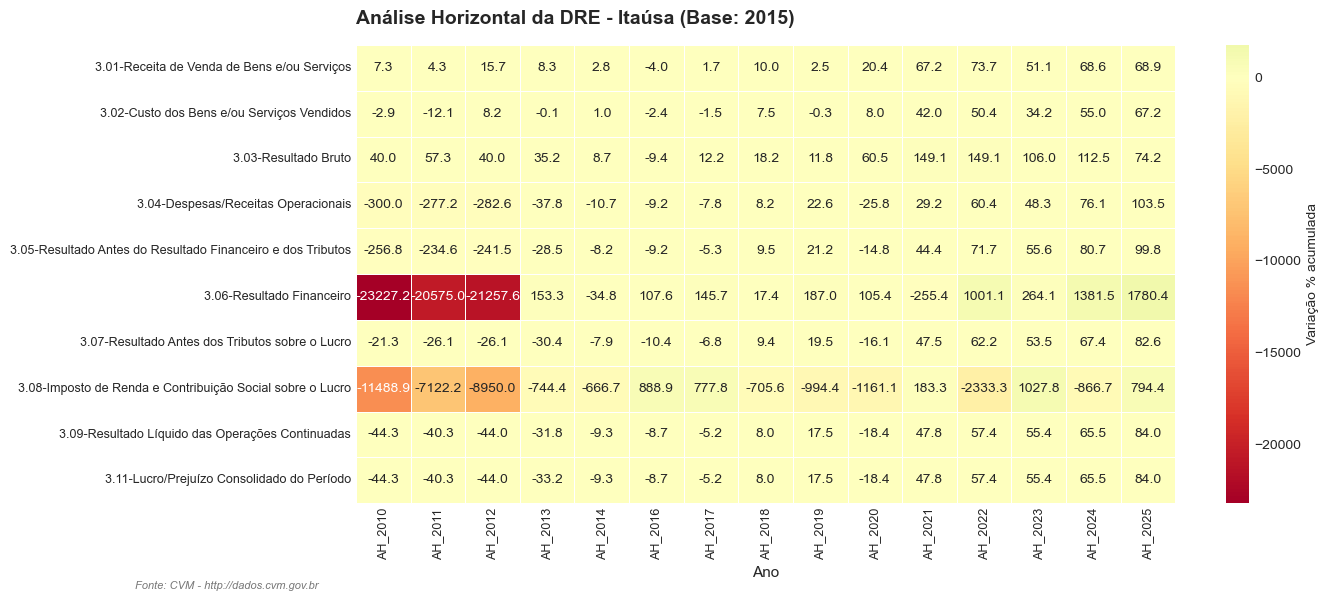

In [56]:
mask_contas = ah_resultado.index.get_level_values('CD_CONTA').str.len() <= 6
ah_plot = ah_resultado[mask_contas]

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

fig, ax = plt.subplots(figsize=(14, max(6, len(ah_plot) * 0.5)))

sns.heatmap(
    ah_plot,
    annot    = True,
    fmt      = '.1f',
    cmap     = 'RdYlGn',
    center   = 0,
    linewidths = 0.5,
    ax       = ax,
    cbar_kws = {'label': 'Variação % acumulada'}
)

ax.set_title(
    f'Análise Horizontal da DRE - Itaúsa (Base: {ANO_BASE})',
    fontsize=14, fontweight='bold', loc='left', pad=15, 
)
ax.set_xlabel('Ano', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='both', labelsize=9)

plt.tight_layout()
plt.figtext(0.1, 0.01, 'Fonte: CVM - http://dados.cvm.gov.br', fontsize=8, color='#777777', style='italic')
plt.show()

## 9. Conclusão e Considerações Finais

A análise horizontal permite identificar tendências estruturais na evolução
das contas da DRE ao longo do tempo - crescimento consistente de receita,
compressão de margens, volatilidade do resultado financeiro, entre outros padrões.

**Para reutilizar este notebook em outra empresa:**
1. Altere `cia` na Seção 4 para localizar o código CVM desejado.
2. Atualize `CD_CVM` com o código confirmado.
3. Ajuste `ANO_BASE` na Seção 7 conforme o período de referência desejado.

**Limitações:**
- Contas sem valor no ano-base são excluídas do cálculo de variação.
- Mudanças no plano de contas entre períodos podem gerar descontinuidades na série.
- A análise é descritiva; a interpretação dos resultados exige contexto setorial e macroeconômico.

**Fonte dos dados:** CVM - http://dados.cvm.gov.br